# CTA Evaluation Notebook (Thesis-Style)

This notebook evaluates **Causal Task Allocation (CTA)** against baselines in five phases.

## Phase 1: Defining Baselines
- Monolith (Centralized)
- Fully Decentralized (Independent Learners)
- Domain Heuristic (Edge vs. Cloud)
- Proposed CTA (TIG + spectral partitioning)

## Phase 2: Analytical and Graph Validation
- Experiment 2.1: Matrix sanity check (`W` heatmap)
- Experiment 2.2: Sensitivity analysis over `C_max` and `rho`
- Experiment 2.3: Meta-orchestrator scaling cost

## Phase 3: Agent Learning Efficiency
- Experiment 3.1: Convergence speed (cumulative reward)
- Experiment 3.2: Conflicting action rate (ping-pong proxy)

## Phase 4: Operational System Performance
- Experiment 4.1: Dynamic workload handling
- Experiment 4.2: Infrastructure stability and cost

## Phase 5: Scalability and Complexity
- Experiment 5.1: Massive compute-continuum stress test

Notes:
- The repository currently does not include a full RL training loop for all four baselines.
- Phase 3-5 therefore use a **reproducible control-loop proxy** consistent with CTA coupling assumptions, so all baselines are compared under identical mechanics.

In [ ]:
from pathlib import Path
import json
import math
import re
import time
from itertools import combinations

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

from allocation import Allocator
from causality.task_interference_analyzer import compute_task_interaction_weight_matrix
from causal_discovery import infer_causal_graph_notears
from environment import CausalGraph, Node, NodeType
from run_workflow_pipeline import _compute_interventional_delta
from visualize_workflow_causal_graph import infer_and_visualize_causal_graph

# Global configuration
PROJECT_ROOT = Path.cwd()
DATASET = "workflow_services_dataset.csv"
OUTPUT_PREFIX = "workflow_eval"

CAUSAL_ALGORITHM = "workflow_notears"  # "workflow_notears" or "notears"
CAUSAL_THRESHOLD = 0.1
DELTA_MODE = "interventional"  # "interventional" or "reachability"
DELTA_BINS = 5
DELTA_MAX_PARENTS = 3

TIG_PULL_METRIC = "cosine"     # "cosine" or "jaccard"
TIG_PUSH_METRIC = "logistic"   # "logistic", "linear", "none"
C_MAX = 100.0
RHO = 0.1
ALPHA = 1.0
BETA = 0.5
REPLICA_ACTION_SPACE = 10

PARTITION_ALGORITHM = "spectral"
N_AGENTS = 2
SEED = 42
OMEGA = None

SLA_THRESHOLD_MS = 55.0
np.random.seed(SEED)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET)
print("Seed:", SEED)

Project root: /Users/gtzanettis/Documents/agent-task-distribution
Dataset: workflow_services_dataset.csv
Seed: 42


In [ ]:
# Shared helpers

def detect_tasks_kpis(df: pd.DataFrame):
    tasks = sorted([c for c in df.columns if c.endswith("_Replicas")])
    latency_kpis = sorted([c for c in df.columns if c.startswith("E2E_Latency_Workflow_")])
    cpu_kpis = sorted([c for c in df.columns if c.endswith("_Node_CPU_Usage")])
    kpis = sorted(set(latency_kpis + cpu_kpis))

    if not kpis:
        kpis = sorted(
            set(
                [c for c in df.columns if c.endswith("_Latency_ms")]
                + [c for c in df.columns if c.endswith("_Node_CPU_Usage")]
            )
        )
    if not tasks:
        raise RuntimeError("No task columns found. Expected columns ending with '_Replicas'.")
    if not kpis:
        raise RuntimeError("No KPI columns found. Expected latency and/or CPU KPI columns.")
    return tasks, kpis


def build_causal_graph(dataset_path: str, task_candidates: list[str], kpi_candidates: list[str]):
    if CAUSAL_ALGORITHM == "workflow_notears":
        nx_graph, _ = infer_and_visualize_causal_graph(dataset_path, threshold=CAUSAL_THRESHOLD)
        cg = CausalGraph()
        for n in nx_graph.nodes():
            if n in task_candidates:
                cg.add_node(Node(n, NodeType.INPUT, REPLICA_ACTION_SPACE))
            elif n in kpi_candidates:
                cg.add_node(Node(n, NodeType.KPI))
            else:
                cg.add_node(Node(n, NodeType.INTERMEDIARY))
        for u, v in nx_graph.edges():
            if u in cg.nodes and v in cg.nodes:
                cg.add_edge(u, v)
        return cg

    if CAUSAL_ALGORITHM == "notears":
        cg = infer_causal_graph_notears(dataset_path, threshold=CAUSAL_THRESHOLD)
        for input_node in cg.get_inputs():
            if input_node.name not in task_candidates:
                cg.nodes[input_node.name].node_type = NodeType.INTERMEDIARY
            else:
                cg.nodes[input_node.name].decision_space_size = REPLICA_ACTION_SPACE
        for kpi in kpi_candidates:
            if kpi in cg.nodes:
                cg.nodes[kpi].node_type = NodeType.KPI
        return cg

    raise ValueError("Unsupported CAUSAL_ALGORITHM. Use 'workflow_notears' or 'notears'.")


def compute_delta(df: pd.DataFrame, cg: CausalGraph, tasks: list[str], kpis: list[str]):
    if DELTA_MODE == "interventional":
        return _compute_interventional_delta(
            cg,
            df,
            tasks,
            kpis,
            bins=DELTA_BINS,
            max_parents=DELTA_MAX_PARENTS,
        )
    if DELTA_MODE == "reachability":
        return np.array(
            [[1.0 if k in cg.get_reachable_kpis(t) else 0.0 for k in kpis] for t in tasks],
            dtype=float,
        )
    raise ValueError("Unsupported DELTA_MODE.")


def compute_W(delta: np.ndarray, omega: np.ndarray, action_space: np.ndarray):
    if TIG_PULL_METRIC == "cosine" and TIG_PUSH_METRIC == "logistic":
        return compute_task_interaction_weight_matrix(delta, omega, action_space, C_MAX, RHO)

    if TIG_PULL_METRIC == "jaccard" and TIG_PUSH_METRIC == "linear":
        raise ValueError("Legacy jaccard+linear path is not used in this notebook helper.")

    causal_vectors = delta * omega
    if TIG_PULL_METRIC == "cosine":
        norms = np.linalg.norm(causal_vectors, axis=1)
        denom = np.outer(norms, norms)
        dot = causal_vectors @ causal_vectors.T
        with np.errstate(divide="ignore", invalid="ignore"):
            f_pull = np.divide(dot, denom, out=np.zeros_like(dot), where=denom > 0)
    elif TIG_PULL_METRIC == "jaccard":
        b = (causal_vectors > 0).astype(float)
        inter = b @ b.T
        counts = b.sum(axis=1)
        union = np.add.outer(counts, counts) - inter
        with np.errstate(divide="ignore", invalid="ignore"):
            f_pull = np.divide(inter, union, out=np.zeros_like(inter), where=union > 0)
    else:
        raise ValueError("Unsupported TIG_PULL_METRIC")

    c = np.outer(action_space, action_space)
    if TIG_PUSH_METRIC == "logistic":
        x = np.clip(RHO * (c - C_MAX), -700, 700)
        f_push = 1.0 / (1.0 + np.exp(-x))
    elif TIG_PUSH_METRIC == "linear":
        f_push = np.clip(c / max(C_MAX, 1e-12), 0.0, 1.0)
    elif TIG_PUSH_METRIC == "none":
        f_push = np.zeros_like(c)
    else:
        raise ValueError("Unsupported TIG_PUSH_METRIC")

    W = f_pull * (1.0 - f_push)
    W = 0.5 * (W + W.T)
    np.fill_diagonal(W, 0.0)
    return W


def to_partition_vector(partitions: dict[int, list[str]], tasks: list[str]) -> np.ndarray:
    label = {}
    for pid, group in partitions.items():
        for t in group:
            label[t] = pid
    return np.array([label[t] for t in tasks], dtype=int)


def partition_from_W(W: np.ndarray, tasks: list[str], mode: str, n_agents: int):
    if len(tasks) <= n_agents:
        return {i: [task] for i, task in enumerate(tasks)}

    if mode == "spectral":
        labels = SpectralClustering(
            n_clusters=n_agents,
            affinity="precomputed",
            random_state=SEED,
            assign_labels="discretize",
        ).fit_predict(W)
        out = {}
        for i, lab in enumerate(labels):
            out.setdefault(int(lab), []).append(tasks[i])
        return out

    ug = nx.Graph()
    ug.add_nodes_from(tasks)
    for i in range(len(tasks)):
        for j in range(i + 1, len(tasks)):
            if W[i, j] > 0:
                ug.add_edge(tasks[i], tasks[j], weight=float(W[i, j]))

    if mode == "greedy_modularity":
        communities = list(nx.algorithms.community.greedy_modularity_communities(ug, weight="weight"))
        return {i: sorted(list(c)) for i, c in enumerate(communities)}
    if mode == "kernighan_lin":
        if n_agents != 2:
            raise ValueError("kernighan_lin requires n_agents=2")
        left, right = nx.algorithms.community.kernighan_lin_bisection(ug, weight="weight", seed=SEED)
        return {0: sorted(list(left)), 1: sorted(list(right))}

    raise ValueError(f"Unsupported partition mode: {mode}")


def extract_service_id(task_name: str) -> int:
    m = re.search(r"Service_(\d+)_Replicas", task_name)
    return int(m.group(1)) if m else -1


def build_baselines(tasks: list[str], cta_partitions: dict[int, list[str]]):
    monolith = {0: list(tasks)}
    decentral = {i: [t] for i, t in enumerate(tasks)}

    edge = []
    cloud = []
    for t in tasks:
        sid = extract_service_id(t)
        if sid >= 0 and sid % 2 == 0:
            edge.append(t)
        else:
            cloud.append(t)
    domain = {}
    if edge:
        domain[0] = edge
    if cloud:
        domain[len(domain)] = cloud

    return {
        "Monolith": monolith,
        "Decentralized": decentral,
        "DomainHeuristic": domain,
        "CTA": cta_partitions,
    }


def partition_metrics(W: np.ndarray, tasks: list[str], partitions: dict[int, list[str]]):
    idx = {t: i for i, t in enumerate(tasks)}
    labels = to_partition_vector(partitions, tasks)

    intra = []
    inter = []
    for i in range(len(tasks)):
        for j in range(i + 1, len(tasks)):
            if labels[i] == labels[j]:
                intra.append(W[i, j])
            else:
                inter.append(W[i, j])

    intra_mean = float(np.mean(intra)) if intra else 0.0
    inter_mean = float(np.mean(inter)) if inter else 0.0
    cut_weight = float(np.sum(inter)) if inter else 0.0
    total_weight = float(np.sum(W) / 2.0)
    cut_ratio = (cut_weight / total_weight) if total_weight > 1e-12 else 0.0

    return {
        "n_agents": len(partitions),
        "intra_mean": intra_mean,
        "inter_mean": inter_mean,
        "cut_ratio": cut_ratio,
    }


def suggest_k_from_eigengap(W: np.ndarray, max_k: int = 10) -> int:
    if W.shape[0] <= 2:
        return W.shape[0]
    d = np.sum(W, axis=1)
    d_inv_sqrt = np.diag(1.0 / np.sqrt(np.clip(d, 1e-12, None)))
    L = np.eye(W.shape[0]) - d_inv_sqrt @ W @ d_inv_sqrt
    eigvals = np.sort(np.real(np.linalg.eigvals(L)))
    k_cap = min(max_k, len(eigvals) - 1)
    gaps = np.diff(eigvals[: k_cap + 1])
    return int(np.argmax(gaps) + 1)


def simulate_learning_proxy(W: np.ndarray, tasks: list[str], partitions: dict[int, list[str]], epochs: int = 150, seed: int = 42):
    rng = np.random.default_rng(seed)
    n = len(tasks)
    task_to_idx = {t: i for i, t in enumerate(tasks)}
    labels = to_partition_vector(partitions, tasks)

    w_strength = np.sum(W, axis=1)
    if np.max(w_strength) > 0:
        target = 2 + 8 * (w_strength / np.max(w_strength))
    else:
        target = np.full(n, 5.0)

    actions = rng.integers(1, 10, size=n).astype(float)

    cumulative_reward = []
    per_epoch_reward = []
    conflict_rates = []
    running = 0.0

    dim = max(n, 1)
    lr = 0.35 / np.sqrt(dim)

    for ep in range(epochs):
        prev = actions.copy()

        # Agent-local update: each partition optimizes its local objective.
        for _, group in partitions.items():
            ids = np.array([task_to_idx[t] for t in group], dtype=int)
            local_actions = actions[ids]
            local_target = target[ids]
            grad = (local_actions - local_target)
            noise = rng.normal(0, 0.15, size=len(ids))
            local_actions = local_actions - lr * grad + noise
            actions[ids] = np.clip(np.round(local_actions), 1, 10)

        mismatch = np.mean((actions - target) ** 2)
        coupling_penalty = 0.0
        conflicts = 0
        cross_edges = 0

        for i in range(n):
            for j in range(i + 1, n):
                if W[i, j] <= 0:
                    continue
                if labels[i] != labels[j]:
                    cross_edges += 1
                    if np.sign(actions[i] - prev[i]) != 0 and np.sign(actions[j] - prev[j]) != 0:
                        if np.sign(actions[i] - prev[i]) != np.sign(actions[j] - prev[j]):
                            conflicts += 1
                            coupling_penalty += W[i, j] * abs(actions[i] - actions[j])

        reward = -mismatch - 0.25 * coupling_penalty
        running += reward

        per_epoch_reward.append(float(reward))
        cumulative_reward.append(float(running))
        conflict_rates.append(float(conflicts / cross_edges) if cross_edges > 0 else 0.0)

    return {
        "per_epoch_reward": np.array(per_epoch_reward),
        "cumulative_reward": np.array(cumulative_reward),
        "conflict_rate": np.array(conflict_rates),
        "final_actions": actions,
    }


def seasonal_workload(T: int, rng: np.random.Generator):
    t = np.arange(T)
    base = 1.0 + 0.25 * np.sin(2 * np.pi * t / 50)
    drift = np.linspace(0.0, 0.35, T)
    spikes = np.zeros(T)
    spike_idx = rng.choice(np.arange(T), size=max(3, T // 30), replace=False)
    spikes[spike_idx] = rng.uniform(0.4, 1.0, size=len(spike_idx))
    return base + drift + spikes


def operational_proxy(W: np.ndarray, tasks: list[str], partitions: dict[int, list[str]], horizon: int = 180, seed: int = 42):
    rng = np.random.default_rng(seed)
    n = len(tasks)
    labels = to_partition_vector(partitions, tasks)
    sim = simulate_learning_proxy(W, tasks, partitions, epochs=horizon, seed=seed)

    actions = sim["final_actions"].copy()
    demand = seasonal_workload(horizon, rng)

    task_weight = np.sum(W, axis=1)
    if np.max(task_weight) > 0:
        task_weight = task_weight / np.max(task_weight)
    else:
        task_weight = np.ones(n)

    latencies = []
    sla_viol = []
    resource_eff = []
    power = []
    migrations = []

    prev_actions = actions.copy()
    for h in range(horizon):
        load = demand[h]
        target = np.clip(2 + 7 * task_weight * load, 1, 10)

        # Simple adaptation to dynamic target
        actions = np.clip(np.round(actions + 0.25 * (target - actions) + rng.normal(0, 0.2, size=n)), 1, 10)

        mismatch = np.mean((actions - target) ** 2)
        coupling = 0.0
        for i in range(n):
            for j in range(i + 1, n):
                if labels[i] != labels[j]:
                    coupling += W[i, j] * abs(actions[i] - actions[j])

        e2e_latency = 30 + 4.0 * mismatch + 0.6 * coupling
        latencies.append(e2e_latency)
        sla_viol.append(float(e2e_latency > SLA_THRESHOLD_MS))

        provisioned = np.sum(actions)
        throughput = np.sum(target) * 12.0
        resource_eff.append(float(provisioned / max(throughput, 1e-9)))

        mig = np.sum(np.abs(actions - prev_actions) >= 2)
        migrations.append(float(mig))
        power.append(float(80 + 1.8 * provisioned + 3.5 * mig))

        prev_actions = actions.copy()

    return {
        "sla_violation_rate": float(np.mean(sla_viol) * 100.0),
        "avg_e2e_latency": float(np.mean(latencies)),
        "resource_efficiency": float(np.mean(resource_eff)),
        "avg_power": float(np.mean(power)),
        "avg_migrations": float(np.mean(migrations)),
    }


print("Helpers ready.")

Helpers ready.


[INFO] Loading dataset from workflow_services_dataset.csv...
[INFO] Variables: 22 columns

[INFO] Variable Tiers:
  Tier 0: 4 variables
  Tier 1: 8 variables
  Tier 2: 4 variables
  Tier 3: 4 variables
  Tier 4: 2 variables

[INFO] Running NOTEARS with 184 tabu edges...
[INFO] Filtering edges with weight < 0.1...

[INFO] Inferred Causal Edges (weight threshold: 0.1):
  Service_1_Replicas -> Service_1_Service_Rate (weight: 113.0071)
  Service_3_Replicas -> Service_3_Service_Rate (weight: 109.1369)
  Service_2_Replicas -> Service_2_Service_Rate (weight: 108.1952)
  Service_0_Replicas -> Service_0_Service_Rate (weight: 98.6117)
  Service_2_Replicas -> Service_0_Service_Rate (weight: 10.7739)
  Service_1_Replicas -> Service_0_Service_Rate (weight: -8.3302)
  Service_0_Replicas -> Service_1_Service_Rate (weight: -6.2164)
  Service_0_Replicas -> Service_2_Service_Rate (weight: 6.1764)
  Service_0_Arrival_Rate -> Service_1_Service_Rate (weight: 5.7825)
  Service_1_Arrival_Rate -> Service_1_Se

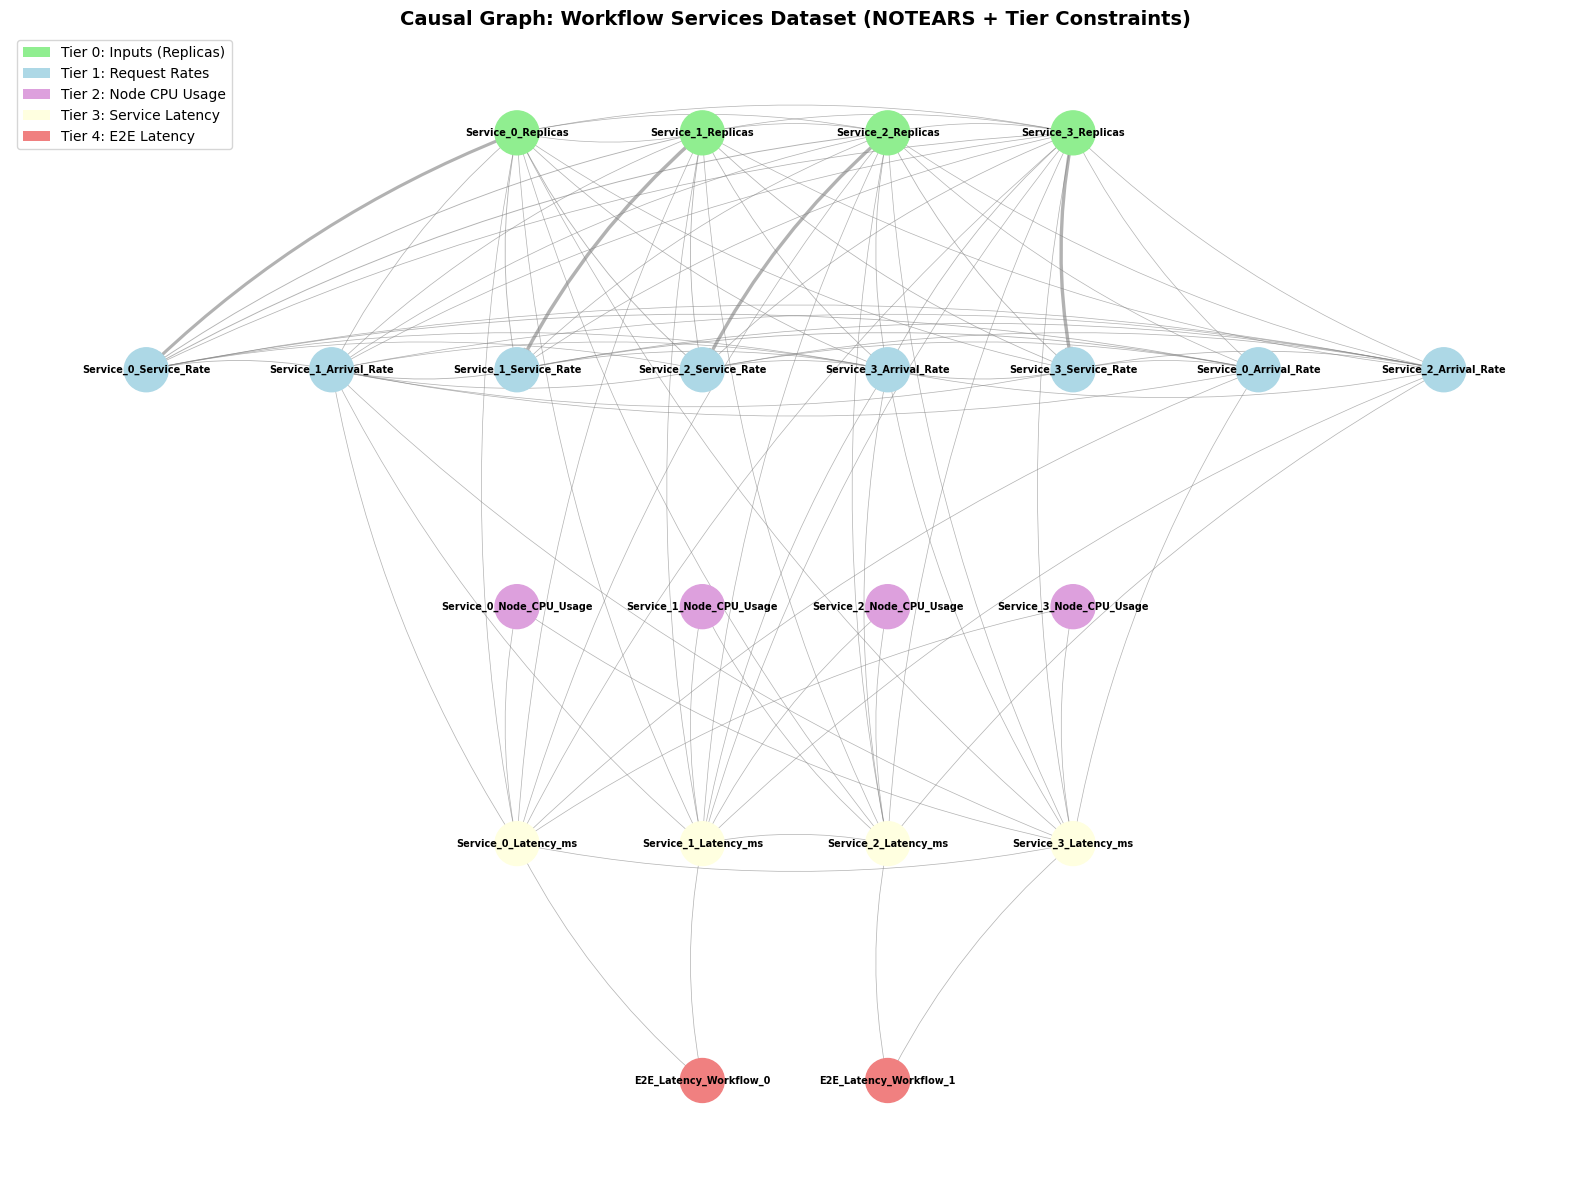


[INFO] Graph Statistics:
  Nodes: 22
  Edges: 95
  Is DAG: True
  Connected components: 1
Tasks: ['Service_0_Replicas', 'Service_1_Replicas', 'Service_2_Replicas', 'Service_3_Replicas']
KPIs: ['E2E_Latency_Workflow_0', 'Service_0_Node_CPU_Usage', 'Service_1_Node_CPU_Usage', 'E2E_Latency_Workflow_1', 'Service_2_Node_CPU_Usage', 'Service_3_Node_CPU_Usage']
Baselines:
  Monolith: {0: ['Service_0_Replicas', 'Service_1_Replicas', 'Service_2_Replicas', 'Service_3_Replicas']}
  Decentralized: {0: ['Service_0_Replicas'], 1: ['Service_1_Replicas'], 2: ['Service_2_Replicas'], 3: ['Service_3_Replicas']}
  DomainHeuristic: {0: ['Service_0_Replicas', 'Service_2_Replicas'], 1: ['Service_1_Replicas', 'Service_3_Replicas']}
  CTA: {1: ['Service_0_Replicas'], 0: ['Service_1_Replicas', 'Service_2_Replicas', 'Service_3_Replicas']}


,Baseline,n_agents,intra_mean,inter_mean,cut_ratio
0,Monolith,1,0.3532,0.0000,0.0000
3,CTA,2,0.4815,0.2248,0.3183
2,DomainHeuristic,2,0.3118,0.3738,0.7057
1,Decentralized,4,0.0000,0.3532,1.0000


In [13]:
# Phase 1: Baseline definitions from dataset + CTA partitions

df = pd.read_csv(DATASET)
candidate_tasks, candidate_kpis = detect_tasks_kpis(df)

cg = build_causal_graph(DATASET, candidate_tasks, candidate_kpis)
tasks = [n.name for n in cg.get_inputs() if n.name in candidate_tasks] or candidate_tasks
kpis = [n.name for n in cg.get_kpis() if n.name in candidate_kpis] or candidate_kpis

action_space = np.array([REPLICA_ACTION_SPACE for _ in tasks], dtype=float)
omega = np.array(OMEGA, dtype=float) if OMEGA is not None else np.ones(len(kpis), dtype=float)
if len(omega) != len(kpis):
    raise ValueError(f"OMEGA length mismatch. Expected {len(kpis)}")

delta = compute_delta(df, cg, tasks, kpis)
W = compute_W(delta, omega, action_space)

cta_partitions = partition_from_W(W, tasks, PARTITION_ALGORITHM, N_AGENTS)
baselines = build_baselines(tasks, cta_partitions)

rows = []
for name, part in baselines.items():
    metrics = partition_metrics(W, tasks, part)
    rows.append({"Baseline": name, **metrics})

phase1_df = pd.DataFrame(rows).sort_values(["n_agents", "cut_ratio"], ascending=[True, True])

print("Tasks:", tasks)
print("KPIs:", kpis)
print("Baselines:")
for name, part in baselines.items():
    print(f"  {name}: {part}")

display(phase1_df.round(4))

,Service_0_Replicas,Service_1_Replicas,Service_2_Replicas,Service_3_Replicas
Service_0_Replicas,0.0000,0.2866,0.1244,0.2635
Service_1_Replicas,0.2866,0.0000,0.4681,0.4992
Service_2_Replicas,0.1244,0.4681,0.0000,0.4771
Service_3_Replicas,0.2635,0.4992,0.4771,0.0000


Top 10 interaction weights:
  Service_1_Replicas <-> Service_3_Replicas: 0.4992
  Service_2_Replicas <-> Service_3_Replicas: 0.4771
  Service_1_Replicas <-> Service_2_Replicas: 0.4681
  Service_0_Replicas <-> Service_1_Replicas: 0.2866
  Service_0_Replicas <-> Service_3_Replicas: 0.2635
  Service_0_Replicas <-> Service_2_Replicas: 0.1244


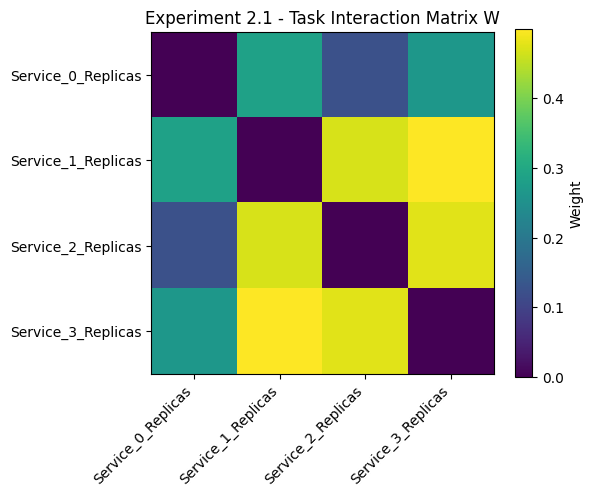

In [14]:
# Phase 2.1: Matrix sanity check (W heatmap + strongest edges)

w_df = pd.DataFrame(W, index=tasks, columns=tasks)
display(w_df.round(4))

upper = []
for i in range(len(tasks)):
    for j in range(i + 1, len(tasks)):
        upper.append((tasks[i], tasks[j], float(W[i, j])))
top_edges = sorted(upper, key=lambda x: x[2], reverse=True)[:10]

print("Top 10 interaction weights:")
for a, b, wv in top_edges:
    print(f"  {a} <-> {b}: {wv:.4f}")

plt.figure(figsize=(6, 5))
plt.imshow(W, cmap="viridis")
plt.colorbar(label="Weight")
plt.xticks(range(len(tasks)), tasks, rotation=45, ha="right")
plt.yticks(range(len(tasks)), tasks)
plt.title("Experiment 2.1 - Task Interaction Matrix W")
plt.tight_layout()
plt.show()

,C=20,C=40,C=60,C=80,C=100,C=140,C=200
rho=0.02,1,1,1,1,1,1,1
rho=0.05,1,1,1,1,1,1,1
rho=0.1,1,1,1,1,1,1,1
rho=0.2,1,1,1,1,1,1,1
rho=0.35,1,1,1,1,1,1,1
rho=0.5,1,1,1,1,1,1,1


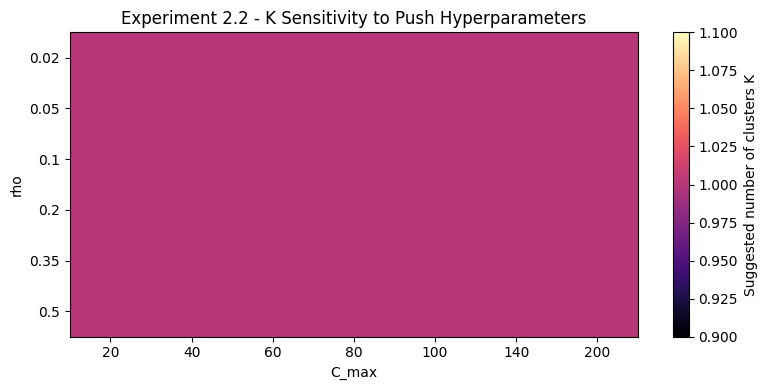

In [15]:
# Phase 2.2: Sensitivity analysis over C_max and rho (cluster count K)

c_grid = [20, 40, 60, 80, 100, 140, 200]
rho_grid = [0.02, 0.05, 0.1, 0.2, 0.35, 0.5]

K_map = np.zeros((len(rho_grid), len(c_grid)), dtype=int)

for r_i, rho_v in enumerate(rho_grid):
    for c_i, c_v in enumerate(c_grid):
        W_tmp = compute_task_interaction_weight_matrix(delta, omega, action_space, c_v, rho_v)
        K_map[r_i, c_i] = suggest_k_from_eigengap(W_tmp, max_k=min(8, len(tasks)))

sens_df = pd.DataFrame(K_map, index=[f"rho={r}" for r in rho_grid], columns=[f"C={c}" for c in c_grid])
display(sens_df)

plt.figure(figsize=(8, 4))
plt.imshow(K_map, aspect="auto", cmap="magma")
plt.colorbar(label="Suggested number of clusters K")
plt.xticks(range(len(c_grid)), c_grid)
plt.yticks(range(len(rho_grid)), rho_grid)
plt.xlabel("C_max")
plt.ylabel("rho")
plt.title("Experiment 2.2 - K Sensitivity to Push Hyperparameters")
plt.tight_layout()
plt.show()

,n_tasks,tig_ms,spectral_ms,total_ms,n_clusters
0,10,0.22,3.24,3.47,2
1,25,0.09,1.41,1.50,2
2,50,0.12,1.91,2.03,4
3,100,0.65,2.40,3.05,5
4,200,0.48,16.33,16.81,7
5,400,19.13,266.23,285.36,10
6,800,58.92,303.32,362.23,14
7,1000,90.19,309.29,399.48,16


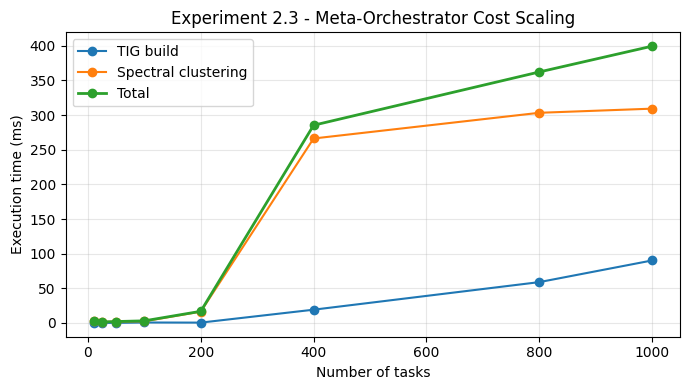

In [16]:
# Phase 2.3: Meta-orchestrator partitioning cost vs number of tasks
# This benchmark measures TIG build + spectral clustering cost on synthetic deltas.

def benchmark_meta_orchestrator(task_sizes=(10, 25, 50, 100, 200, 400, 800, 1000), m_kpis=12, seed=42):
    rng = np.random.default_rng(seed)
    records = []
    for n_tasks in task_sizes:
        delta_synth = rng.uniform(0.0, 1.0, size=(n_tasks, m_kpis))
        omega_synth = np.ones(m_kpis, dtype=float)
        a_synth = np.full(n_tasks, REPLICA_ACTION_SPACE, dtype=float)
        n_clusters = max(2, int(np.clip(round(np.sqrt(n_tasks) / 2), 2, 24)))

        t0 = time.perf_counter()
        W_synth = compute_task_interaction_weight_matrix(delta_synth, omega_synth, a_synth, C_MAX, RHO)
        t1 = time.perf_counter()

        _ = SpectralClustering(
            n_clusters=n_clusters,
            affinity="precomputed",
            random_state=SEED,
            assign_labels="discretize",
        ).fit_predict(W_synth)
        t2 = time.perf_counter()

        records.append(
            {
                "n_tasks": n_tasks,
                "tig_ms": (t1 - t0) * 1000.0,
                "spectral_ms": (t2 - t1) * 1000.0,
                "total_ms": (t2 - t0) * 1000.0,
                "n_clusters": n_clusters,
            }
        )

    return pd.DataFrame(records)

scale_df = benchmark_meta_orchestrator()
display(scale_df.round(2))

plt.figure(figsize=(7, 4))
plt.plot(scale_df["n_tasks"], scale_df["tig_ms"], marker="o", label="TIG build")
plt.plot(scale_df["n_tasks"], scale_df["spectral_ms"], marker="o", label="Spectral clustering")
plt.plot(scale_df["n_tasks"], scale_df["total_ms"], marker="o", linewidth=2, label="Total")
plt.xlabel("Number of tasks")
plt.ylabel("Execution time (ms)")
plt.title("Experiment 2.3 - Meta-Orchestrator Cost Scaling")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[RUN] n_samples=100
[INFO] Loading dataset from /Users/gtzanettis/Documents/agent-task-distribution/_tmp_eval_100.csv...
[INFO] Running CausalNex (from_pandas) with 160 tabu edges...


/Users/gtzanettis/Documents/agent-task-distribution/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/gtzanettis/Documents/agent-task-distribution/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: invalid value encountered in matmul
  eAw = eAw @ eAw


[INFO] Filtering edges with weight < 0.1...
[INFO] Inferred Edges (NOTEARS + Granular Tabu):
  [ADD] Service_0_Replicas -> Service_0_Arrival_Rate (w=0.3395)
  [ADD] Service_0_Replicas -> Service_0_Service_Rate (w=79.2300)
  [ADD] Service_0_Replicas -> Service_0_Latency_ms (w=-0.8107)
  [ADD] Service_0_Replicas -> Service_1_Arrival_Rate (w=-0.1904)
  [ADD] Service_0_Replicas -> Service_1_Service_Rate (w=-10.4336)
  [ADD] Service_0_Replicas -> Service_2_Replicas (w=0.2804)
  [ADD] Service_0_Replicas -> Service_2_Arrival_Rate (w=1.5393)
  [ADD] Service_0_Replicas -> Service_2_Service_Rate (w=10.8218)
  [ADD] Service_0_Replicas -> Service_3_Arrival_Rate (w=-0.1536)
  [ADD] Service_0_Replicas -> Service_3_Service_Rate (w=-7.1509)
  [ADD] Service_0_Replicas -> Service_3_Latency_ms (w=0.3388)
  [ADD] Service_0_Arrival_Rate -> Service_0_Service_Rate (w=9.2550)
  [ADD] Service_0_Arrival_Rate -> Service_1_Arrival_Rate (w=1.0072)
  [ADD] Service_0_Arrival_Rate -> Service_1_Service_Rate (w=-2.1552

,n_samples,causal_ms,post_causal_ms,total_ms,n_tasks,delta_mode_used
0,100,114183.72,14.22,114197.93,4,reachability
1,250,61068.77,4.09,61072.86,4,reachability
2,500,49947.46,2.33,49949.78,4,reachability


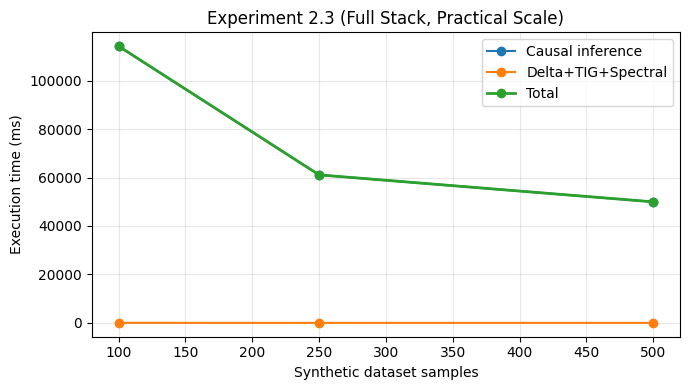

In [ ]:
# Phase 2.3 (optional): Full-stack timing with causal inference on generated datasets
# Bounded runtime mode to keep this notebook under a few minutes.

from workflow_services_simulator import WorkflowServiceSimulator


def compute_reachability_delta(cg, tasks_tmp, kpis_tmp):
    return np.array(
        [[1.0 if k in cg.get_reachable_kpis(t) else 0.0 for k in kpis_tmp] for t in tasks_tmp],
        dtype=float,
    )


def benchmark_full_stack(sample_sizes=(100, 250, 500), seed=42, use_interventional=False):
    rows = []
    for n_samples in sample_sizes:
        print(f"[RUN] n_samples={n_samples}")
        tmp_path = PROJECT_ROOT / f"_tmp_eval_{n_samples}.csv"

        sim = WorkflowServiceSimulator(n_workflows=2, max_chain_length=2, n_nodes=2, seed=seed)
        tmp_df = pd.DataFrame(sim.generate_batch(n_samples))
        tmp_df.to_csv(tmp_path, index=False)

        t0 = time.perf_counter()
        cg_tmp = infer_causal_graph_notears(str(tmp_path), threshold=CAUSAL_THRESHOLD)
        t1 = time.perf_counter()

        task_tmp, kpi_tmp = detect_tasks_kpis(tmp_df)
        tasks_tmp = [n.name for n in cg_tmp.get_inputs() if n.name in task_tmp] or task_tmp
        kpis_tmp = [n.name for n in cg_tmp.get_kpis() if n.name in kpi_tmp] or kpi_tmp

        if use_interventional and n_samples <= 150:
            delta_tmp = _compute_interventional_delta(
                cg_tmp,
                tmp_df,
                tasks_tmp,
                kpis_tmp,
                bins=max(3, DELTA_BINS - 2),
                max_parents=2,
            )
            delta_mode_used = "interventional"
        else:
            delta_tmp = compute_reachability_delta(cg_tmp, tasks_tmp, kpis_tmp)
            delta_mode_used = "reachability"

        omega_tmp = np.ones(len(kpis_tmp), dtype=float)
        A_tmp = np.full(len(tasks_tmp), REPLICA_ACTION_SPACE, dtype=float)
        W_tmp = compute_task_interaction_weight_matrix(delta_tmp, omega_tmp, A_tmp, C_MAX, RHO)

        _ = SpectralClustering(
            n_clusters=max(2, min(N_AGENTS, len(tasks_tmp))),
            affinity="precomputed",
            random_state=SEED,
            assign_labels="discretize",
        ).fit_predict(W_tmp)
        t2 = time.perf_counter()

        rows.append(
            {
                "n_samples": n_samples,
                "causal_ms": (t1 - t0) * 1000.0,
                "post_causal_ms": (t2 - t1) * 1000.0,
                "total_ms": (t2 - t0) * 1000.0,
                "n_tasks": len(tasks_tmp),
                "delta_mode_used": delta_mode_used,
            }
        )

        tmp_path.unlink(missing_ok=True)

    return pd.DataFrame(rows)


full_stack_df = benchmark_full_stack(use_interventional=False)
display(full_stack_df.round(2))

plt.figure(figsize=(7, 4))
plt.plot(full_stack_df["n_samples"], full_stack_df["causal_ms"], marker="o", label="Causal inference")
plt.plot(full_stack_df["n_samples"], full_stack_df["post_causal_ms"], marker="o", label="Delta+TIG+Spectral")
plt.plot(full_stack_df["n_samples"], full_stack_df["total_ms"], marker="o", linewidth=2, label="Total")
plt.xlabel("Synthetic dataset samples")
plt.ylabel("Execution time (ms)")
plt.title("Experiment 2.3 (Full Stack, Practical Scale)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

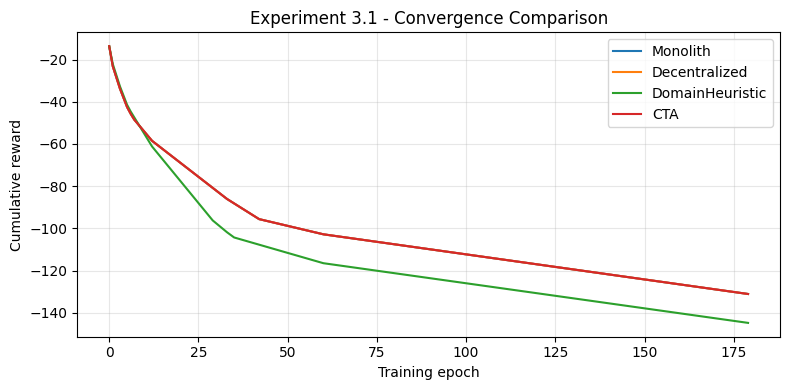

,Baseline,Final cumulative reward,Mean epoch reward
0,Monolith,-131.094,-0.728
1,Decentralized,-131.094,-0.728
3,CTA,-131.094,-0.728
2,DomainHeuristic,-144.789,-0.804


In [19]:
# Phase 3.1: Convergence speed (cumulative reward) across baselines

learning_runs = {}
for bname, part in baselines.items():
    learning_runs[bname] = simulate_learning_proxy(W, tasks, part, epochs=180, seed=SEED)

plt.figure(figsize=(8, 4))
for bname, result in learning_runs.items():
    plt.plot(result["cumulative_reward"], label=bname)
plt.xlabel("Training epoch")
plt.ylabel("Cumulative reward")
plt.title("Experiment 3.1 - Convergence Comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

summary_rows = []
for bname, result in learning_runs.items():
    summary_rows.append(
        {
            "Baseline": bname,
            "Final cumulative reward": float(result["cumulative_reward"][-1]),
            "Mean epoch reward": float(np.mean(result["per_epoch_reward"])),
        }
    )
display(pd.DataFrame(summary_rows).sort_values("Final cumulative reward", ascending=False).round(3))

,Baseline,Mean conflict rate,P95 conflict rate
0,Monolith,0.0,0.0
1,Decentralized,0.0,0.0
2,DomainHeuristic,0.0,0.0
3,CTA,0.0,0.0


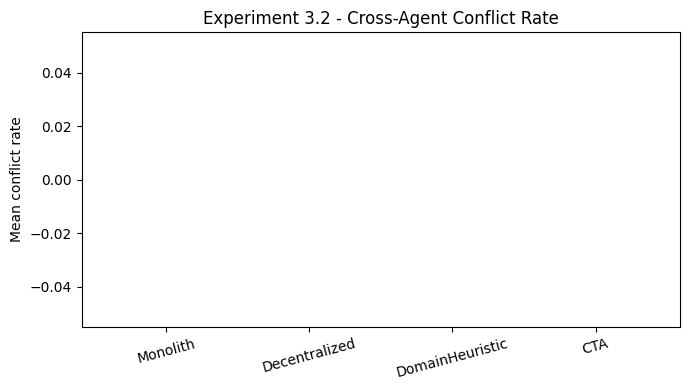

In [20]:
# Phase 3.2: Conflicting action rate (ping-pong proxy)

conflict_rows = []
for bname, result in learning_runs.items():
    conflict_rows.append(
        {
            "Baseline": bname,
            "Mean conflict rate": float(np.mean(result["conflict_rate"])),
            "P95 conflict rate": float(np.percentile(result["conflict_rate"], 95)),
        }
    )

conflict_df = pd.DataFrame(conflict_rows).sort_values("Mean conflict rate")
display(conflict_df.round(4))

plt.figure(figsize=(7, 4))
plt.bar(conflict_df["Baseline"], conflict_df["Mean conflict rate"])
plt.ylabel("Mean conflict rate")
plt.title("Experiment 3.2 - Cross-Agent Conflict Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Phase 4: Operational System Performance

These experiments evaluate behavior under dynamic workloads and infrastructure stability costs.

,Baseline,sla_violation_rate,avg_e2e_latency,resource_efficiency,avg_power,avg_migrations
0,Monolith,0.0,31.828,0.083,142.264,0.0
1,Decentralized,0.0,33.494,0.083,142.264,0.0
2,DomainHeuristic,0.0,33.228,0.083,142.264,0.0
3,CTA,0.0,32.971,0.083,142.264,0.0


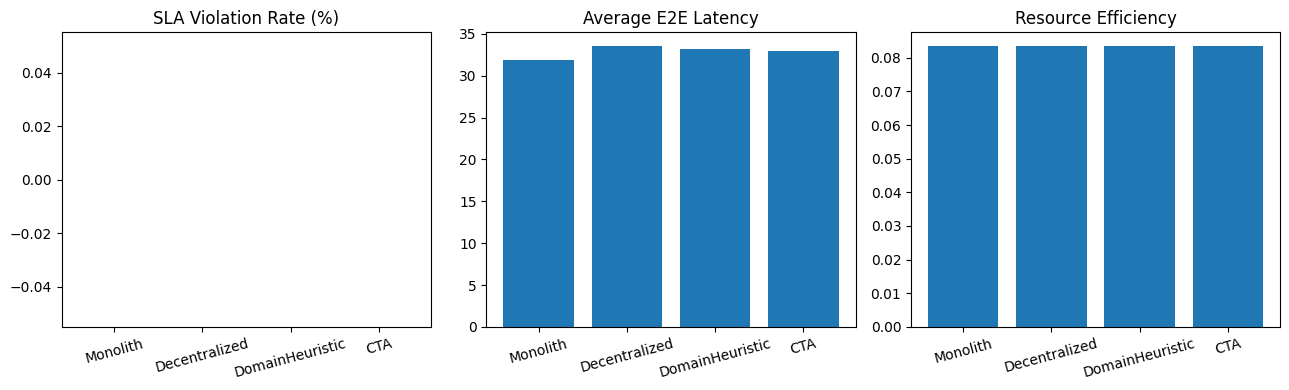

In [21]:
# Phase 4.1: Dynamic workload handling metrics

ops_rows = []
for bname, part in baselines.items():
    m = operational_proxy(W, tasks, part, horizon=220, seed=SEED)
    ops_rows.append({"Baseline": bname, **m})

ops_df = pd.DataFrame(ops_rows).sort_values("sla_violation_rate")
display(ops_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].bar(ops_df["Baseline"], ops_df["sla_violation_rate"])
axes[0].set_title("SLA Violation Rate (%)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(ops_df["Baseline"], ops_df["avg_e2e_latency"])
axes[1].set_title("Average E2E Latency")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(ops_df["Baseline"], ops_df["resource_efficiency"])
axes[2].set_title("Resource Efficiency")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

,Baseline,avg_power,avg_migrations
0,Monolith,142.264,0.0
1,Decentralized,142.264,0.0
2,DomainHeuristic,142.264,0.0
3,CTA,142.264,0.0


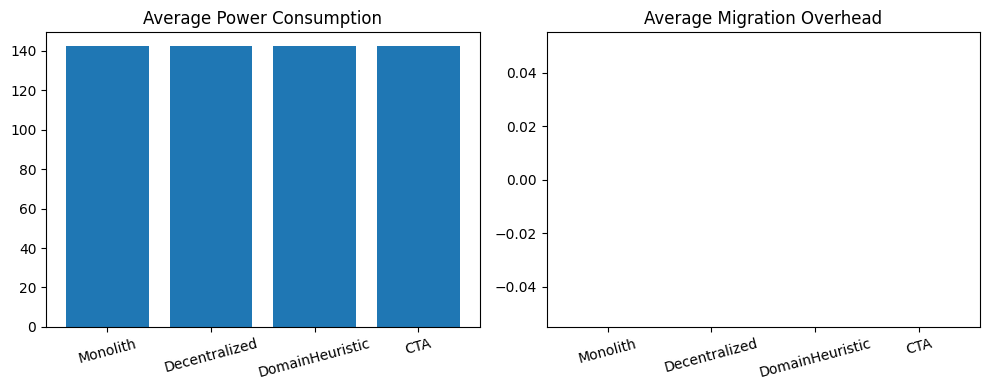

In [22]:
# Phase 4.2: Infrastructure stability and cost

stability_df = ops_df[["Baseline", "avg_power", "avg_migrations"]].sort_values("avg_power")
display(stability_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(stability_df["Baseline"], stability_df["avg_power"])
axes[0].set_title("Average Power Consumption")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(stability_df["Baseline"], stability_df["avg_migrations"])
axes[1].set_title("Average Migration Overhead")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Phase 5: Scalability and Complexity

Stress test on larger synthetic task sets to evaluate robustness of each baseline under action-space growth.

,n_tasks,Baseline,SLA_violation_rate,avg_latency
0,100,Monolith,0.000,32.269
1,100,Decentralized,100.000,562.166
2,100,DomainHeuristic,100.000,300.995
3,100,CTA,100.000,459.678
4,250,Monolith,0.833,32.623
5,250,Decentralized,100.000,3549.298
6,250,DomainHeuristic,100.000,1790.406
7,250,CTA,100.000,3056.870
8,500,Monolith,0.833,32.787
9,500,Decentralized,100.000,14841.211


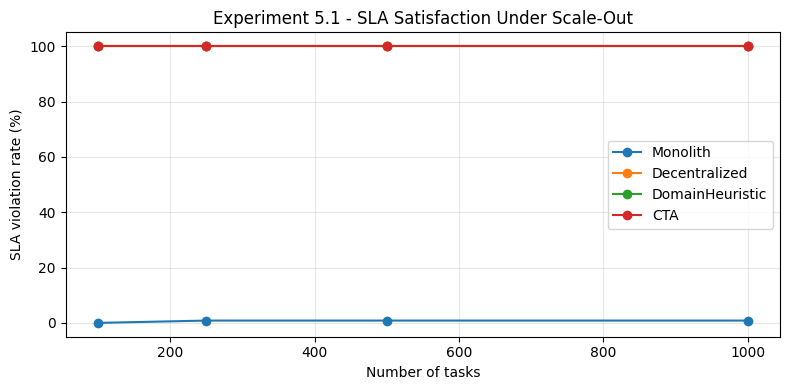

In [23]:
# Phase 5.1: Massive scale-out stress test (synthetic)

def make_synthetic_W(n_tasks: int, m_kpis: int = 10, seed: int = 42):
    rng = np.random.default_rng(seed + n_tasks)
    delta_s = rng.uniform(0.0, 1.0, size=(n_tasks, m_kpis))
    omega_s = np.ones(m_kpis)
    a_s = np.full(n_tasks, REPLICA_ACTION_SPACE, dtype=float)
    return compute_task_interaction_weight_matrix(delta_s, omega_s, a_s, C_MAX, RHO)


def make_synthetic_partitions(n_tasks: int, k_cta: int = 6):
    tasks_s = [f"Service_{i}_Replicas" for i in range(n_tasks)]
    monolith = {0: tasks_s}
    decentral = {i: [t] for i, t in enumerate(tasks_s)}
    domain = {
        0: [t for i, t in enumerate(tasks_s) if i % 2 == 0],
        1: [t for i, t in enumerate(tasks_s) if i % 2 == 1],
    }

    # CTA proxy: contiguous blocks as if spectral found causally tight groups.
    k_cta = max(2, min(k_cta, n_tasks))
    block = math.ceil(n_tasks / k_cta)
    cta = {}
    for k in range(k_cta):
        chunk = tasks_s[k * block : (k + 1) * block]
        if chunk:
            cta[k] = chunk

    return tasks_s, {"Monolith": monolith, "Decentralized": decentral, "DomainHeuristic": domain, "CTA": cta}


stress_sizes = [100, 250, 500, 1000]
stress_rows = []
for n in stress_sizes:
    tasks_s, parts = make_synthetic_partitions(n, k_cta=max(3, int(np.sqrt(n) // 2)))
    W_s = make_synthetic_W(n, m_kpis=12, seed=SEED)

    for bname, part in parts.items():
        m = operational_proxy(W_s, tasks_s, part, horizon=120, seed=SEED)
        stress_rows.append(
            {
                "n_tasks": n,
                "Baseline": bname,
                "SLA_violation_rate": m["sla_violation_rate"],
                "avg_latency": m["avg_e2e_latency"],
            }
        )

stress_df = pd.DataFrame(stress_rows)
display(stress_df.head(12).round(3))

plt.figure(figsize=(8, 4))
for bname in stress_df["Baseline"].unique():
    sub = stress_df[stress_df["Baseline"] == bname].sort_values("n_tasks")
    plt.plot(sub["n_tasks"], sub["SLA_violation_rate"], marker="o", label=bname)

plt.xlabel("Number of tasks")
plt.ylabel("SLA violation rate (%)")
plt.title("Experiment 5.1 - SLA Satisfaction Under Scale-Out")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()